In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import requests
from pathlib import Path
from datetime import datetime, timedelta
import time

In [23]:
raw_data=pd.read_csv("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/agri_bio_papers_2018_2023.csv")

In [24]:
raw_data.shape

(1210996, 20)

In [25]:
raw_data.columns

Index(['doi', 'publication_year', 'author_count', 'countries_distinct_count',
       'institutions_distinct_count', 'type', 'corresponding_author_ids',
       'corresponding_institution_ids', 'source_id', 'source_display_name',
       'source_2yr_mean_citedness', 'source_type', 'source_is_core',
       'source_is_in_doaj', 'source_issn', 'source_has_issn',
       'apc_list_value_usd', 'primary_topic_id', 'primary_topic_display_name',
       'referenced_works_count'],
      dtype='str')

In [26]:
raw_data.type.value_counts()

type
article                    1149646
review                       38344
paratext                      5570
erratum                       3776
letter                        3646
reference-entry               2766
editorial                     2353
book-chapter                  1657
other                         1335
book                           717
preprint                       631
dissertation                   213
retraction                     211
dataset                         76
report                          48
supplementary-materials          6
book-section                     1
Name: count, dtype: int64

In [68]:
type_stats = (
    raw_data.groupby("type")["referenced_works_count"]
    .agg(total="sum", mean="mean", count="size")
    .reset_index()
    .sort_values("count", ascending=False)
)
type_stats.head()

,type,total,mean,count
0,article,30148546,26.224199,1149646
15,review,3889509,101.437226,38344
10,paratext,22116,3.970557,5570
7,erratum,6631,1.756091,3776
8,letter,50447,13.836259,3646


In [27]:
raw_data.source_display_name.value_counts()

source_display_name
International Journal of Current Microbiology and Applied Sciences    10820
Frontiers in Plant Science                                             9550
Journal of Pharmacognosy and Phytochemistry                            7578
Scientific Reports                                                     7538
Agronomy                                                               6749
                                                                      ...  
Innovative Computing Review                                               1
Nature-Based Solutions                                                    1
Big Data Research                                                         1
Canadian Journal of Nursing Research                                      1
The Microbe                                                               1
Name: count, Length: 51262, dtype: int64

In [28]:
true_label=raw_data.source_is_core.value_counts()[True]/raw_data.shape[0]
print(f"True label (is_core=True) percentage: {true_label:.2%}")
false_label=raw_data.source_is_core.value_counts()[False]/raw_data.shape[0]
print(f"False label (is_core=False) percentage: {false_label:.2%}")

True label (is_core=True) percentage: 54.91%
False label (is_core=False) percentage: 45.09%


In [29]:
true_label=raw_data.source_is_in_doaj.value_counts()[True]/raw_data.shape[0]
print(f"True label (source_is_in_doaj=True) percentage: {true_label:.2%}")
false_label=raw_data.source_is_in_doaj.value_counts()[False]/raw_data.shape[0]
print(f"False label (source_is_in_doaj=False) percentage: {false_label:.2%}")

True label (source_is_in_doaj=True) percentage: 28.85%
False label (source_is_in_doaj=False) percentage: 71.15%


In [30]:
# #Extract 2 year exact citation

# def get_exact_2y_cites(
#     raw_data_processed,
#     id_col="openalex_id",
#     date_col="publication_date",
#     email=None,
#     sleep=0.12,
#     checkpoint_path=None,
#     save_every=100,
#     timeout=20,
#     max_retries=4,
# ):
#     """
#     Compute exact citation windows per paper using OpenAlex API.

#     Appends to raw_data_processed:
#       - citations_year_1_exact: from publication day to +364 days
#       - citations_year_2_exact: from +365 to +729 days
#       - citations_first_2y_exact: year_1 + year_2

#     Designed for large batches with resume/checkpoint support.
#     """

#     base_url = "https://api.openalex.org/works"
#     session = requests.Session()
#     user_agent = f"mailto:{email}" if email else "OpenAlex-Exact2Y-Citations"
#     session.headers.update({"User-Agent": user_agent})

#     def _normalize_work_id(work_id):
#         s = str(work_id).strip()
#         if s.startswith("http"):
#             s = s.rstrip("/").split("/")[-1]
#         return s

#     def _query_count(short_id, from_dt, to_dt):
#         params = {
#             "filter": f"cites:{short_id},from_publication_date:{from_dt},to_publication_date:{to_dt}",
#             "select": "id",
#             "per_page": 1,
#         }
#         if email:
#             params["mailto"] = email

#         for attempt in range(1, max_retries + 1):
#             try:
#                 resp = session.get(base_url, params=params, timeout=timeout)
#                 status = resp.status_code
#                 if status in (429, 500, 502, 503, 504):
#                     raise requests.HTTPError(f"HTTP {status}: retryable")
#                 resp.raise_for_status()
#                 count = resp.json().get("meta", {}).get("count", 0)
#                 return int(count) if count is not None else 0
#             except Exception as e:
#                 if attempt == max_retries:
#                     print(f"ERROR final ({short_id}): {e}")
#                     return np.nan
#                 backoff = (2 ** (attempt - 1)) * sleep + random.uniform(0, sleep)
#                 time.sleep(backoff)
#         return np.nan

#     # Pre-normalize work IDs once for efficient lookups
#     work_ids_short = raw_data_processed[id_col].astype(str).map(_normalize_work_id)

#     # Resume from checkpoint if available
#     cached = {}
#     cp = Path(checkpoint_path) if checkpoint_path else None
#     if cp and cp.exists():
#         cp_raw_data_processed = pd.read_csv(cp)
#         required_cache_cols = {
#             id_col,
#             "citations_year_1_exact",
#             "citations_year_2_exact",
#             "citations_first_2y_exact",
#         }
#         if required_cache_cols.issubset(set(cp_raw_data_processed.columns)):
#             cp_ids_short = cp_raw_data_processed[id_col].astype(str).map(_normalize_work_id)
#             for short_id, y1, y2, total in zip(
#                 cp_ids_short,
#                 cp_raw_data_processed["citations_year_1_exact"],
#                 cp_raw_data_processed["citations_year_2_exact"],
#                 cp_raw_data_processed["citations_first_2y_exact"],
#             ):
#                 cached[short_id] = (y1, y2, total)
#             print(f"Loaded checkpoint with {len(cached)} papers from {cp}")

#     results = dict(cached)
#     total = len(raw_data_processed)
#     processed_now = 0

#     for i, (short_id, pub_date_str) in enumerate(zip(work_ids_short, raw_data_processed[date_col]), 1):
#         if short_id in results and not any(pd.isna(v) for v in results[short_id]):
#             if i % 200 == 0 or i == total:
#                 print(f"  progress: {i}/{total} (cached/resumed)")
#             continue

#         try:
#             pub_date = datetime.strptime(str(pub_date_str), "%Y-%m-%d")
#         except Exception:
#             results[short_id] = (np.nan, np.nan, np.nan)
#             continue

#         y1_start = pub_date
#         y1_end = pub_date + timedelta(days=364)
#         y2_start = pub_date + timedelta(days=365)
#         y2_end = pub_date + timedelta(days=729)

#         y1_count = _query_count(short_id, y1_start.strftime("%Y-%m-%d"), y1_end.strftime("%Y-%m-%d"))
#         y2_count = _query_count(short_id, y2_start.strftime("%Y-%m-%d"), y2_end.strftime("%Y-%m-%d"))

#         if pd.isna(y1_count) or pd.isna(y2_count):
#             total_2y = np.nan
#         else:
#             total_2y = int(y1_count) + int(y2_count)

#         results[short_id] = (y1_count, y2_count, total_2y)
#         processed_now += 1

#         # Save incremental checkpoint for large runs
#         if cp and (processed_now % save_every == 0):
#             tmp = pd.DataFrame([
#                 {
#                     id_col: k,
#                     "citations_year_1_exact": v[0],
#                     "citations_year_2_exact": v[1],
#                     "citations_first_2y_exact": v[2],
#                 }
#                 for k, v in results.items()
#             ])
#             tmp.to_csv(cp, index=False)
#             print(f"  checkpoint saved: {len(tmp)} rows")

#         time.sleep(sleep)

#         if i % 25 == 0 or i == total:
#             print(f"  progress: {i}/{total}")

#     lookup = work_ids_short.map(lambda k: results.get(k, (np.nan, np.nan, np.nan)))
#     raw_data_processed["citations_year_1_exact"] = lookup.map(lambda v: v[0])
#     raw_data_processed["citations_year_2_exact"] = lookup.map(lambda v: v[1])
#     raw_data_processed["citations_first_2y_exact"] = lookup.map(lambda v: v[2])

#     # Final checkpoint write
#     if cp:
#         final_cp = pd.DataFrame({
#             id_col: work_ids_short,
#             "citations_year_1_exact": raw_data_processed["citations_year_1_exact"],
#             "citations_year_2_exact": raw_data_processed["citations_year_2_exact"],
#             "citations_first_2y_exact": raw_data_processed["citations_first_2y_exact"],
#         }).drop_duplicates(subset=[id_col], keep="first")
#         final_cp.to_csv(cp, index=False)
#         print(f"Final checkpoint saved to {cp}")

#     return raw_data_processed

# # Apply exact 2-year enrichment (resume-safe for large collections)
# checkpoint_file = Path("/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml")

# get_exact_2y_cites(
#     raw_data,
#     id_col="openalex_id",
#     date_col="publication_date",
#     email=None,
#     sleep=0.12,
#     checkpoint_path=checkpoint_file,
#     save_every=100,
#     timeout=20,
#     max_retries=4,
# )

### Simple EDA for works.csv
This section splits numeric and categorical variables, summarizes them, and plots basic distributions.

In [31]:
missing_counts = raw_data.isna().sum()
missing_pct = (missing_counts / len(raw_data) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
}).sort_values("missing_count", ascending=False)

missing_summary.head(10)

,missing_count,missing_pct
source_2yr_mean_citedness,1210996,100.00
apc_list_value_usd,721358,59.57
corresponding_institution_ids,308303,25.46
doi,88868,7.34
source_issn,49575,4.09
corresponding_author_ids,42542,3.51
source_display_name,1,0.00
publication_year,0,0.00
countries_distinct_count,0,0.00
author_count,0,0.00


In [32]:
preferred = [c for c in raw_data.columns if c.lower() == "corresponding_author_id"]
if preferred:
    corresponding_author_col = preferred[0]
else:
    candidates = [
        c
        for c in raw_data.columns
        if "corresponding" in c.lower() and "author" in c.lower()
    ]
    if not candidates:
        raise KeyError("No corresponding author id column found in raw_data")
    corresponding_author_col = candidates[0]

missing_corresponding = raw_data[raw_data[corresponding_author_col].isna()]
missing_corresponding[["doi"]].head(10)

,doi
1,https://doi.org/10.1093/nar/gky1022
7,https://doi.org/10.12705/code.2018
16,https://doi.org/10.4103/ijmr.ijmr_85_17
20,https://doi.org/10.2903/j.efsa.2018.5500
45,https://doi.org/10.2903/j.efsa.2018.5206
104,https://doi.org/10.1111/nph.15343
123,https://doi.org/10.1038/nbt.4110
131,https://doi.org/10.1038/s41588-018-0116-x
162,https://doi.org/10.1016/j.micpath.2018.08.034
163,https://doi.org/10.1016/j.soilbio.2018.06.025


count    489638.000000
mean       2744.636599
std        1447.895996
min           0.000000
25%        2000.000000
50%        2890.000000
75%        3618.000000
max       11690.000000
Name: apc_list_value_usd, dtype: float64


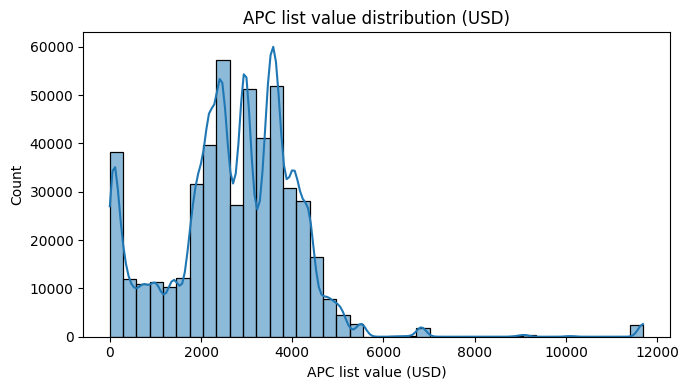

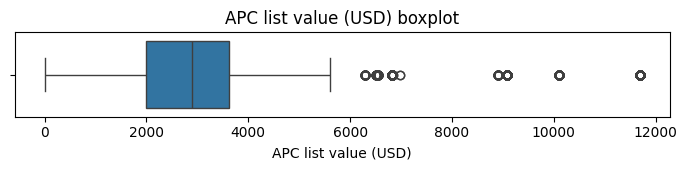

In [ ]:
# Distribution of APC list values (USD)
apc_list = raw_data["apc_list_value_usd"]

print(apc_list.describe())

plt.figure(figsize=(7, 4))
sns.histplot(apc_list, bins=40, kde=True)
plt.title("APC list value distribution (USD)")
plt.xlabel("APC list value (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 1.8))
sns.boxplot(x=apc_list)
plt.title("APC list value (USD) boxplot")
plt.xlabel("APC list value (USD)")
plt.tight_layout()
plt.show()

In [63]:
apc_list_filtered = raw_data.loc[
    raw_data["apc_list_value_usd"] >= 6000,
    ["source_display_name", "apc_list_value_usd"],
]
apc_list_filtered.head(100)

,source_display_name,apc_list_value_usd
8,Nature Microbiology,11690.0
24,Nature,11690.0
28,Nature,11690.0
37,Cell,10100.0
39,Nature Plants,11690.0
...,...,...
988,Nature Methods,11690.0
990,Trends in Ecology & Evolution,6830.0
1018,Molecular Cell,9080.0
1029,Trends in Plant Science,6830.0


In [66]:
apc_list_filtered = (
    raw_data.loc[raw_data["apc_list_value_usd"] >= 6000, ["source_display_name", "apc_list_value_usd"]]
    .groupby("source_display_name", as_index=False)["apc_list_value_usd"]
    .max()
    .sort_values("apc_list_value_usd", ascending=False)
)
apc_list_filtered.shape[0]

75

In [35]:
print(raw_data.is_oa.value_counts())
raw_data.oa_status.value_counts()
raw_data.oa_status.value_counts().plot(kind='bar')
plt.show()


AttributeError: 'DataFrame' object has no attribute 'is_oa'

count      235.000000
mean      5153.174468
std       4125.727777
min        199.000000
25%       2325.000000
50%       4018.000000
75%       6513.500000
max      24828.000000
Name: count, dtype: float64


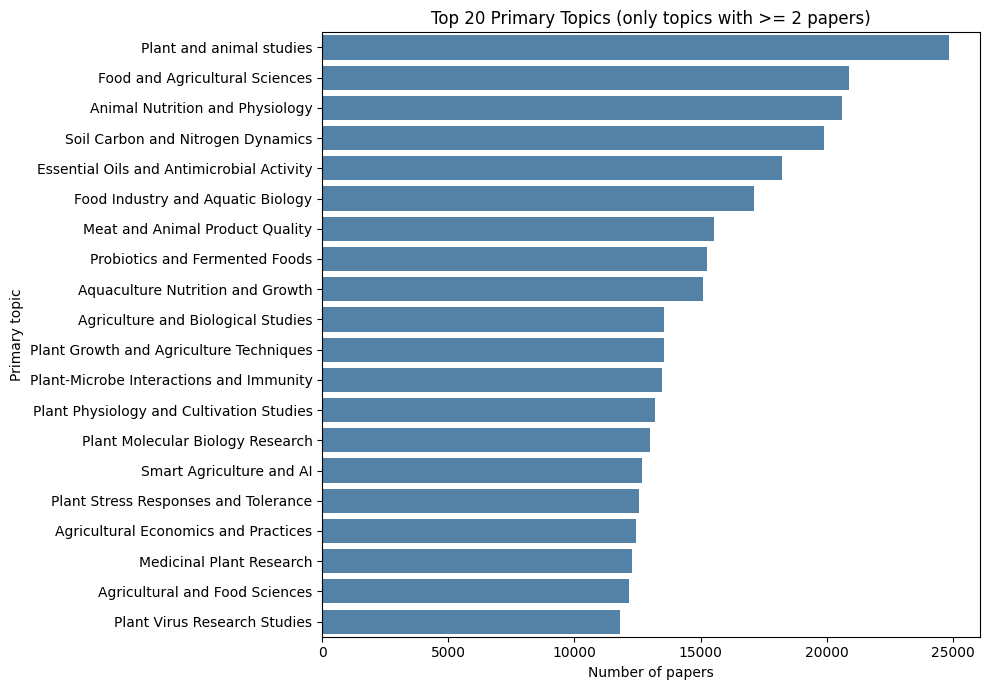

In [71]:
# 1) Count topics
topic_counts = (raw_data["primary_topic_display_name"].value_counts())
print(topic_counts.describe())
# 2) Remove rare topics (example: keep topics with at least 2 papers)
min_count = 2
topic_counts_filtered = topic_counts[topic_counts >= min_count]
# 3) Keep top N for readability
top_n = 20
top_topics = topic_counts_filtered.head(top_n)
# 4) Plot
plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    orient="h",
    color="steelblue"
)
plt.title(f"Top {top_n} Primary Topics (only topics with >= {min_count} papers)")
plt.xlabel("Number of papers")
plt.ylabel("Primary topic")
plt.tight_layout()
plt.show()

In [ ]:
topic_journal_counts = (
    raw_data.dropna(subset=["primary_topic_display_name", "source_display_name"])
    .groupby(["primary_topic_display_name", "source_display_name"])
    .size()
    .reset_index(name="paper_count")
)
topic_totals = (
    topic_journal_counts
    .groupby("primary_topic_display_name", as_index=False)["paper_count"]
    .sum()
    .rename(columns={"paper_count": "topic_total_papers"})
)
top_journal_per_topic = (
    topic_journal_counts
    .sort_values(["primary_topic_display_name", "paper_count"], ascending=[True, False])
    .groupby("primary_topic_display_name", as_index=False)
    .head(1)
    .merge(topic_totals, on="primary_topic_display_name", how="left")
    .sort_values("topic_total_papers", ascending=False)
)

top_journal_per_topic.head(20)

,primary_topic_display_name,source_display_name,paper_count,topic_total_papers
185,Plant and animal studies,Ecology and Evolution,445,24828
99,Food and Agricultural Sciences,Jurnal Ilmu dan Teknologi Pangan (ITEPA),163,20875
37,Animal Nutrition and Physiology,Journal of Animal Science,1896,20609
219,Soil Carbon and Nitrogen Dynamics,The Science of The Total Environment,937,19885
84,Essential Oils and Antimicrobial Activity,Molecules,644,18219
93,Food Industry and Aquatic Biology,Известия вузов Пищевая технология,305,17107
139,Meat and Animal Product Quality,Foods,809,15525
199,Probiotics and Fermented Foods,Frontiers in Microbiology,553,15239
39,Aquaculture Nutrition and Growth,Aquaculture,1574,15091
22,Agriculture and Biological Studies,Taurian Scientific Herald,327,13566


count    1.210996e+06
mean     2.020081e+03
std      1.408819e+00
min      2.018000e+03
25%      2.019000e+03
50%      2.020000e+03
75%      2.021000e+03
max      2.023000e+03
Name: publication_year, dtype: float64


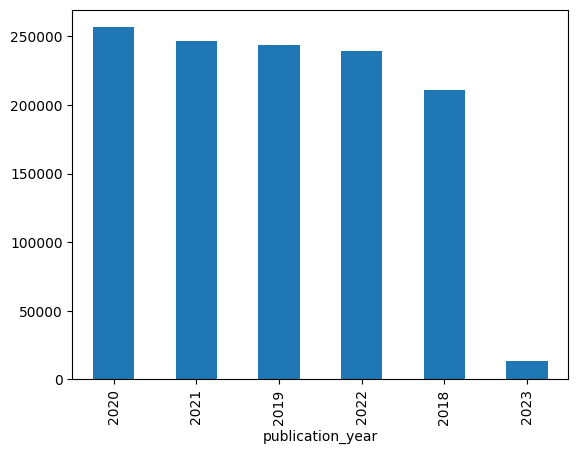

In [76]:
print(raw_data.publication_year.describe())
raw_data.publication_year.value_counts().plot(kind='bar')
plt.show()


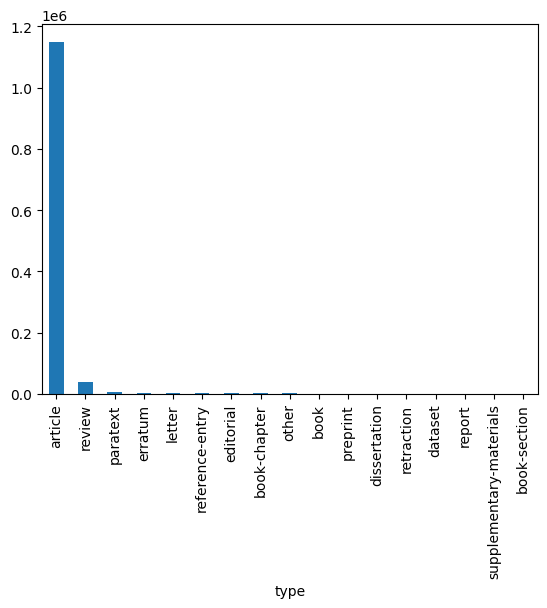

In [39]:

raw_data.type.value_counts().plot(kind='bar')
plt.show()

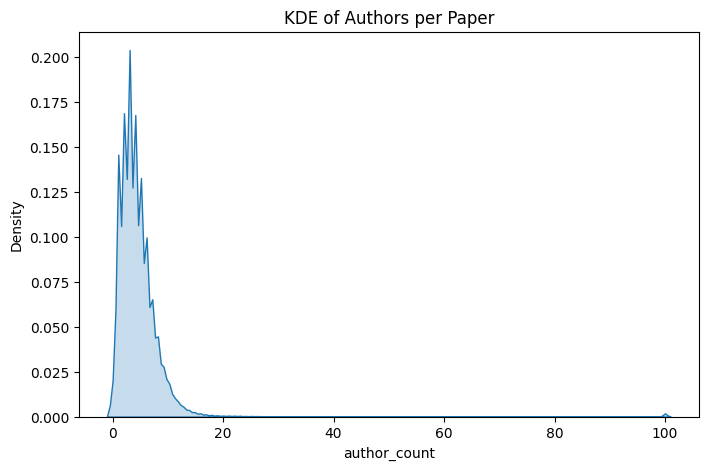

In [79]:
authors = pd.to_numeric(raw_data["author_count"], errors="coerce").dropna()
plt.figure(figsize=(8, 5))
sns.kdeplot(authors, fill=True, bw_adjust=1.0)
plt.title("KDE of Authors per Paper")
plt.xlabel("author_count")
plt.ylabel("Density")
plt.show()

In [ ]:
# import ast
# import re

# # 1. Extract + normalize in one step
# def extract_keywords(keyword_str):
#     try:
#         data = ast.literal_eval(keyword_str)
#         cleaned = []
#         for item in data:
#             kw = item["display_name"].lower()
#             kw = re.sub(r"\(.*?\)", "", kw)  # remove parentheses
#             kw = kw.strip()
#             cleaned.append(kw)
#         return cleaned
#     except:
#         return []

# raw_data = raw_data.copy()  # IMPORTANT
# raw_data["keywords"] = raw_data["keywords"].apply(extract_keywords)


In [ ]:
print(raw_data.shape)
raw_data.to_csv('/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml')

(3959, 48)
